# Análisis Exploratorio de Datos (EDA)
**Instituto Tecnológico Superior de Ciudad Constitución**  
Ingeniería en Sistemas Computacionales

---
## 1. ¿Qué es EDA?

El **Análisis Exploratorio de Datos** (Exploratory Data Analysis, EDA) es una etapa inicial del proceso de ciencia de datos en la que se examinan los datos de manera sistemática antes de aplicar modelos estadísticos o de machine learning. Fue formalizado por el estadístico **John W. Tukey** en su obra *Exploratory Data Analysis* (1977).

Su propósito es comprender la estructura, distribución, calidad y relaciones presentes en los datos mediante resúmenes estadísticos y visualizaciones.

### Finalidades y objetivos

| Objetivo | Descripción |
|---|---|
| Comprender la estructura | Conocer el número de variables, tipos de dato y registros |
| Detectar valores atípicos | Identificar outliers que puedan distorsionar el análisis |
| Identificar valores faltantes | Localizar NaN o datos vacíos para tratarlos adecuadamente |
| Analizar distribuciones | Entender cómo se distribuyen los valores de cada variable |
| Descubrir relaciones | Encontrar correlaciones o dependencias entre variables |
| Validar supuestos | Verificar si los datos cumplen los requisitos de modelos posteriores |
| Generar hipótesis | Formular preguntas que guíen el análisis profundo |

> **Fuente:** Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

---
## 2. Fases y Tipos de EDA

### Fases del EDA

**Fase 1 — Inspección inicial**  
Revisar dimensiones, tipos de datos, primeras filas y resumen estadístico básico.

**Fase 2 — Análisis de calidad**  
Detectar valores nulos, duplicados, inconsistencias de formato y datos corruptos.

**Fase 3 — Análisis univariado**  
Estudiar cada variable de forma individual: media, mediana, desviación estándar, histogramas.

**Fase 4 — Análisis bivariado y multivariado**  
Examinar relaciones entre dos o más variables: correlaciones, diagramas de dispersión, heatmaps.

**Fase 5 — Conclusiones y preparación**  
Documentar hallazgos y decidir qué transformaciones aplicar antes del modelado.

---

### Tipos de EDA

| Dimensión | Tipo | Descripción |
|---|---|---|
| Según el método | **Gráfico** | Usa visualizaciones (histogramas, boxplots, scatter plots) |
| Según el método | **No gráfico** | Usa estadísticas numéricas (media, varianza, tablas de frecuencia) |
| Según variables | **Univariado** | Analiza una sola variable a la vez |
| Según variables | **Bivariado** | Analiza la relación entre dos variables |
| Según variables | **Multivariado** | Analiza múltiples variables simultáneamente |

> **Fuente:** McKinney, W. (2022). *Python for Data Analysis*, 3rd ed. O'Reilly Media.

---
## 3. Herramientas más utilizadas

| Herramienta | Lenguaje | Uso principal |
|---|---|---|
| **Pandas** | Python | Manipulación y resumen de datos tabulares |
| **NumPy** | Python | Operaciones numéricas y estadísticas |
| **Matplotlib** | Python | Visualizaciones estáticas de bajo nivel |
| **Seaborn** | Python | Visualizaciones estadísticas de alto nivel |
| **Plotly** | Python/JS | Gráficos interactivos |
| **ydata-profiling** | Python | Reporte EDA automático completo |
| **SciPy** | Python | Pruebas estadísticas |
| **R + ggplot2** | R | Visualización estadística avanzada |
| **Tableau / Power BI** | Visual | Exploración sin código, orientada a negocio |

> **Fuente:** VanderPlas, J. (2016). *Python Data Science Handbook*. O'Reilly Media.

---
## 4. Ejemplo de EDA en Python

Se utiliza el dataset clásico **Iris** de scikit-learn, que contiene medidas de 150 flores de tres especies.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

# Carga del dataset
iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.drop(columns='target', inplace=True)

print('Dataset cargado correctamente.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset cargado correctamente.
Dimensiones: 150 filas x 5 columnas


### Fase 1: Inspección inicial

In [12]:
print('Primeras filas:')
display(df.head())

print('\nTipos de dato:')
print(df.dtypes)

print('\nResumen estadístico:')
display(df.describe().round(2))

Primeras filas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Tipos de dato:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Resumen estadístico:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Fase 2: Análisis de calidad

In [13]:
print('Valores nulos por columna:')
print(df.isnull().sum())

print(f'\nRegistros duplicados: {df.duplicated().sum()}')

print('\nDistribución de clases (species):')
print(df['species'].value_counts())

Valores nulos por columna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Registros duplicados: 1

Distribución de clases (species):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Fase 3: Análisis univariado — Histogramas

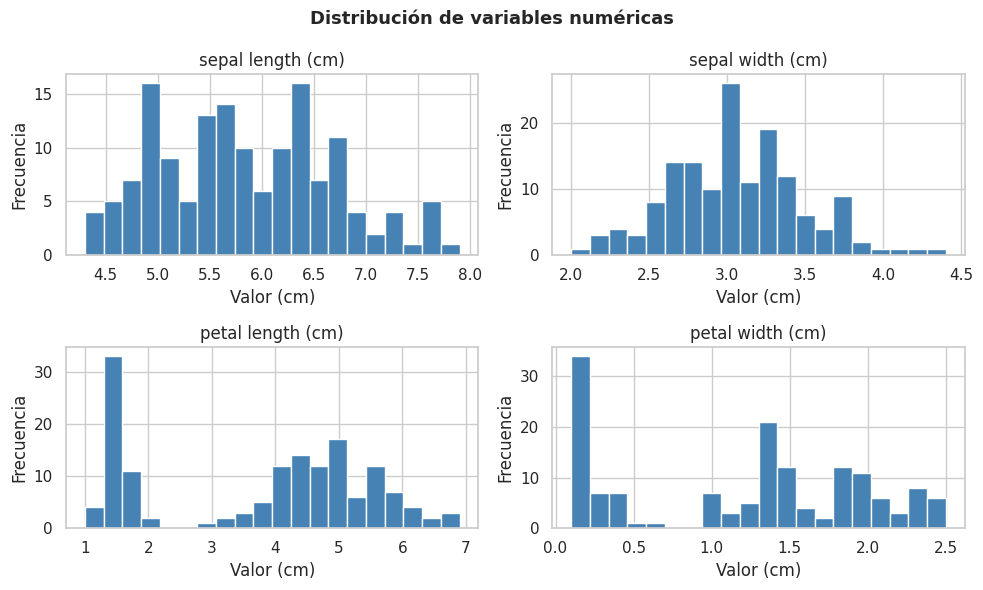

In [14]:
num_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor (cm)')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas.png', dpi=120, bbox_inches='tight')
plt.show()

### Fase 3: Análisis univariado — Boxplots por especie

/tmp/ipykernel_56814/1951957841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_56814/1951957841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_56814/1951957841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_56814/1951957841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

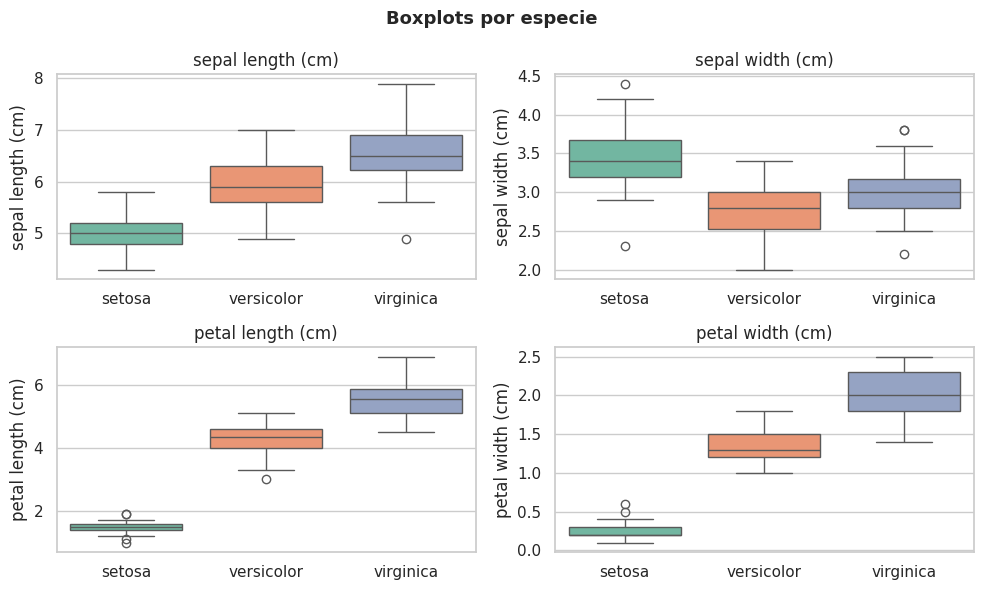

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots por especie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

### Fase 4: Análisis bivariado — Matriz de correlación

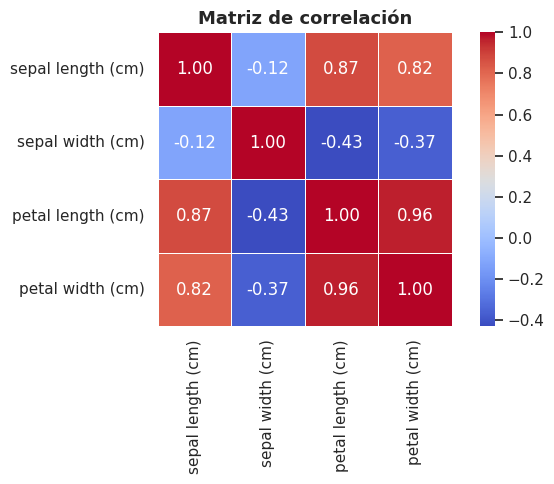


Observación: petal length y petal width tienen correlación muy alta (≈0.96).


In [16]:
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Matriz de correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nObservación: petal length y petal width tienen correlación muy alta (≈0.96).')

### Fase 4: Análisis multivariado — Pairplot

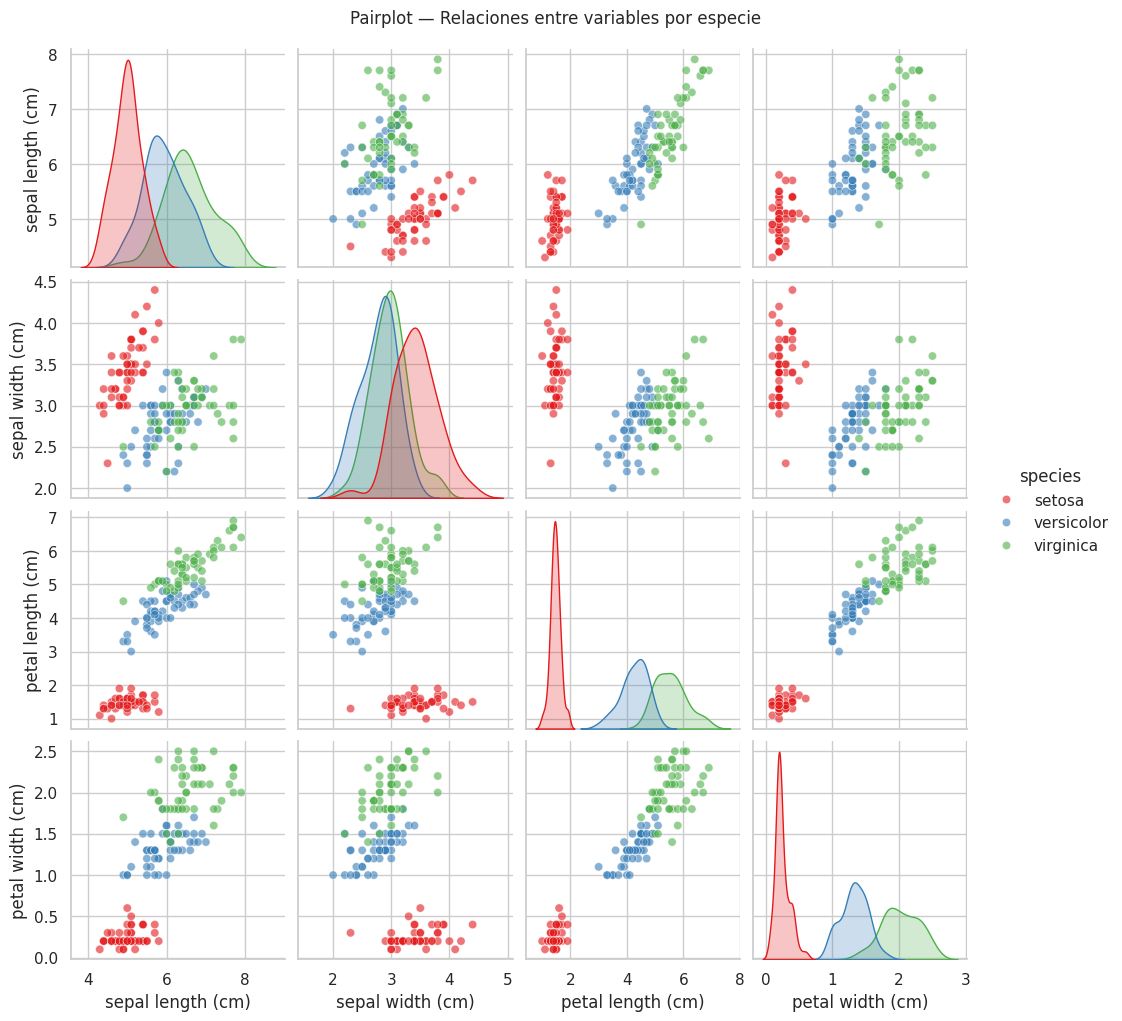

In [17]:
g = sns.pairplot(df, hue='species', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot — Relaciones entre variables por especie', y=1.02, fontsize=12)
plt.savefig('pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

### Fase 5: Conclusiones del EDA

- El dataset no contiene valores nulos ni duplicados relevantes.
- Las variables `petal length` y `petal width` muestran una correlación de **0.96**, la más alta del dataset.
- La especie **setosa** es claramente separable del resto por sus dimensiones de pétalo.
- Las variables de pétalo son más informativas que las de sépalo para distinguir especies.
- Los boxplots revelan algunos outliers leves en `sepal width` para la clase versicolor.

> **Fuente:** Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics, 7(2), 179–188.